In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

I0000 00:00:1778691828.941284   46684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778691828.976587   46684 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778691829.704490   46684 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Source: Data Source :http://data.seoul.go.kr/
SOUTH KOREA PUBLIC HOLIDAYS. URL: publicholidays.go.kr

In [2]:
dataset_cols = [
    "bike_count",
    "hour",
    "temp",
    "humidity",
    "wind",
    "visibility",
    "dew_pt_temp",
    "radiation",
    "rain",
    "snow",
    "functional"
]

df = pd.read_csv(
    "/home/datvt/Documents/projects/mta/ky2t5_deeplearning/python-data-demo/notebooks/tut/data/SeoulBikeData.csv",
    encoding="latin1"
).drop(["Date", "Holiday", "Seasons"], axis=1)

In [3]:
df.head()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [4]:
df.columns = dataset_cols
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [5]:
df["functional"] = (df["functional"] == "Yes").astype(int)

In [6]:
df.head(7500)

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
7495,0,7,10.9,70,0.7,2000,5.6,0.00,0.0,0.0,0
7496,0,8,11.4,66,0.8,1991,5.2,0.18,0.0,0.0,0
7497,0,9,12.8,57,1.2,1838,4.4,0.55,0.0,0.0,0
7498,0,10,14.8,51,1.0,1998,4.7,1.07,0.0,0.0,0


In [7]:
# chỉ lấy hour = 12 -> để  bài toán đơn giản hơn
df = df[df["hour"] == 12]
# do df không còn phụ thuộc vào hour nữa -> drop column hour để  dataset trở nên đơn giản hơn
df = df.drop(["hour"], axis=1)

In [8]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


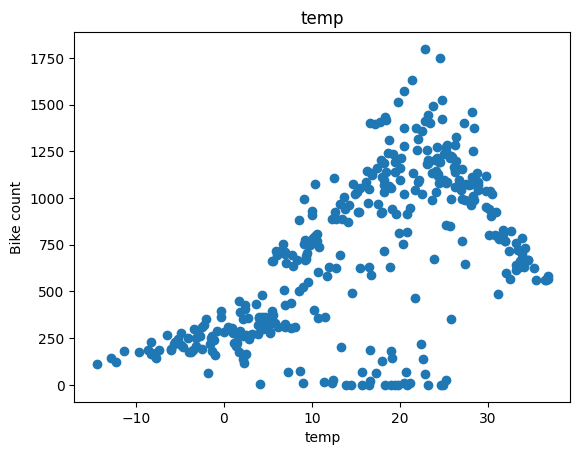

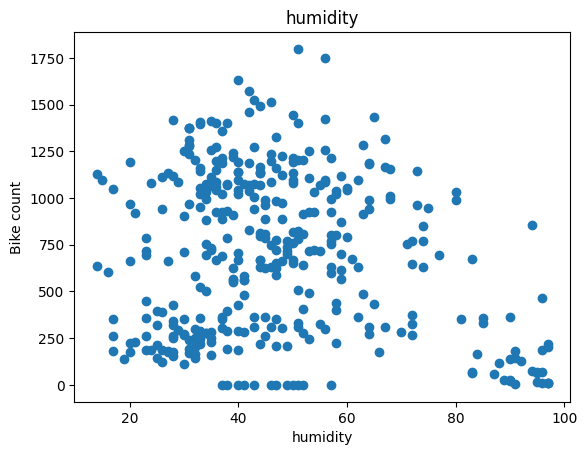

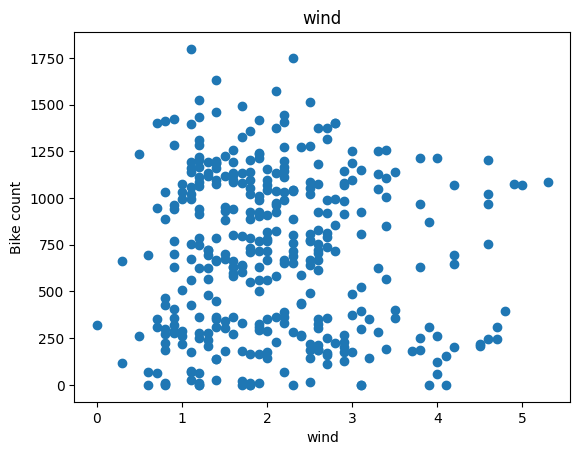

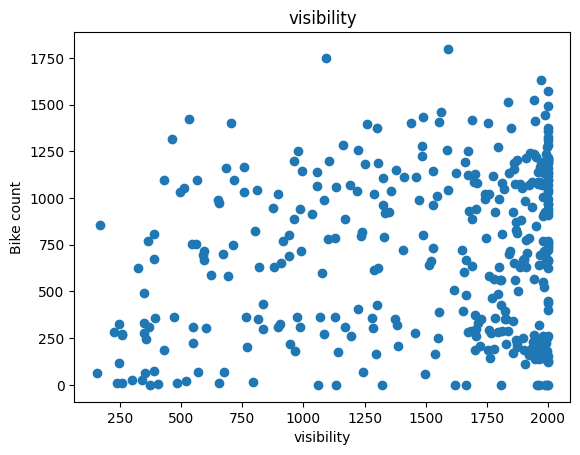

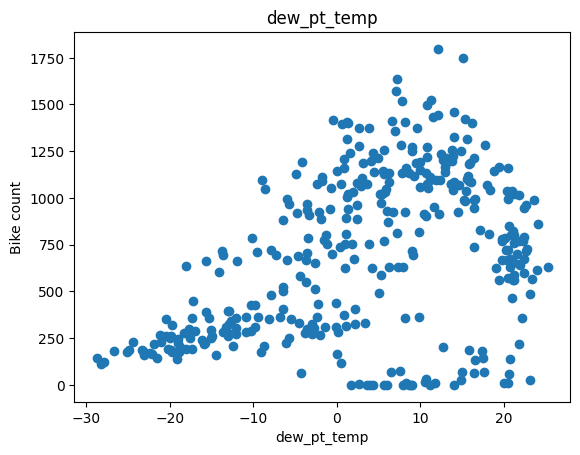

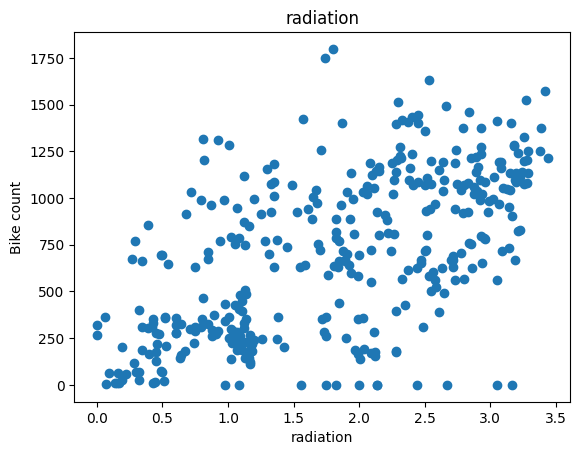

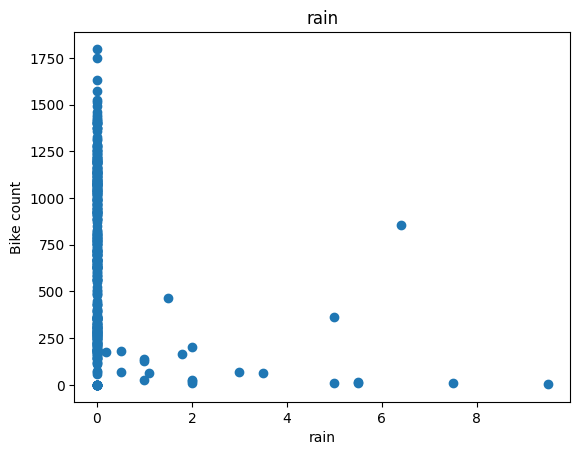

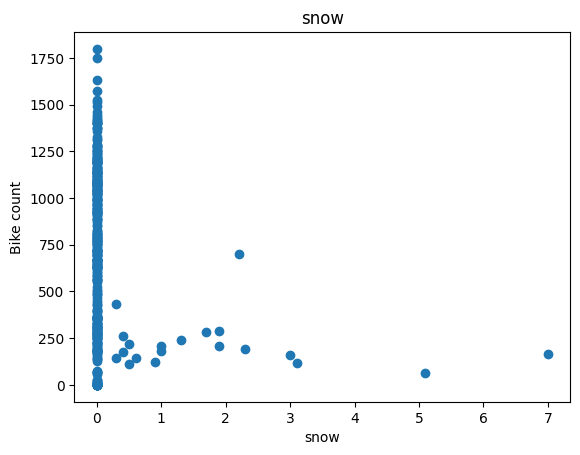

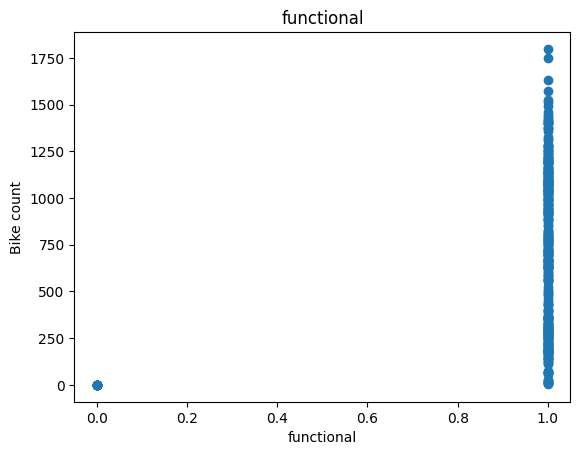

In [9]:
for label in df.columns[1:]:
  plt.scatter(df[label], df["bike_count"])
  plt.title(label)
  plt.ylabel("Bike count")
  plt.xlabel(label)
  plt.show()

In [10]:
df = df.drop(["wind", "visibility", "functional"], axis=1)

In [11]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


### Train/valid/test dataset

In [63]:
# - df.sample(frac=1) -> lấy 100% dữ liệu nhưng theo thứ tự ngẫu nhiên, shuffle dataset
# - tính vị trí chia dataset để  làm bộ dữ liệu: 60% và 80%
# train  # 60%
# val    # 20%
# test   # 20%

# shuffle dataset
shuffled_df = df.sample(frac=1, random_state=42)

# tính index chia
train_end = int(0.6 * len(shuffled_df))
val_end = int(0.8 * len(shuffled_df))

# split
train = shuffled_df[:train_end]
val = shuffled_df[train_end:val_end]
test = shuffled_df[val_end:]

In [64]:
def get_xy(dataframe, y_label, x_labels=None):
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe phải là pandas DataFrame")
    
    # Tạo bản copy của dataframe để  tránh thay đổi dữ liệu gốc
    dataframe = copy.deepcopy(dataframe)

    # Nếu không truyền danh sách feature (x_labels)
    # -> lấy tất cả cột ngoại trừ y_label làm input X
    if x_labels is None:
        X = dataframe[
            [c for c in dataframe.columns if c != y_label]
        ].values

    else:
        # Nếu chỉ có 1 feature
        # reshape(-1, 1) để chuyển:
        # (n,) -> (n,1)
        # vì sklearn / numpy thường yêu cầu ma trận 2 chiều
        if len(x_labels) == 1:
            X = dataframe[x_labels[0]].values.reshape(-1, 1)

        # Nếu có nhiều feature
        # lấy trực tiếp thành matrix
        else:
            X = dataframe[x_labels].values

    # Lấy target y
    # reshape(-1,1) để tạo vector cột
    y = dataframe[y_label].values.reshape(-1, 1)

    # Ghép X và y theo chiều ngang
    # ví dụ:
    # X shape = (100,3)
    # y shape = (100,1)
    # -> data shape = (100,4)
    data = np.hstack((X, y))

    # return:
    # data = toàn bộ dữ liệu đã ghép
    # X = features
    # y = target
    return data, X, y

In [65]:
print(type(train))

<class 'pandas.DataFrame'>


In [66]:
print(train.columns)

Index(['bike_count', 'temp', 'humidity', 'dew_pt_temp', 'radiation', 'rain',
       'snow'],
      dtype='str')


In [67]:
_, X_train_temp, y_train_temp = get_xy(train, "bike_count", x_labels=["temp"])
_, X_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temp"])
_, X_test_temp, y_test = get_xy(test, "bike_count", x_labels=["temp"])

In [68]:
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
temp_reg.score(X_val_temp, y_val_temp)

0.3916506446071202

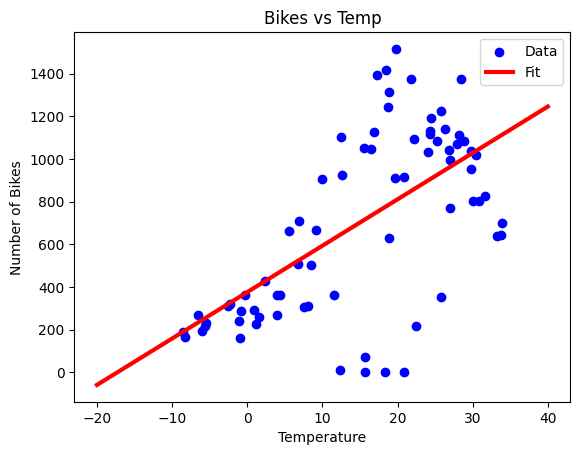

In [70]:
# Vẽ các điểm dữ liệu thực tế dưới dạng scatter plot
# X_val_temp: nhiệt độ
# y_val_temp: số lượng xe đạp tương ứng
plt.scatter(X_val_temp, y_val_temp, label="Data", color="blue")

# Tạo 100 giá trị x liên tục từ -20 đến 40
# để vẽ đường dự đoán mượt hơn
x = tf.linspace(-20, 40, 100)

# Dùng model temp_reg để dự đoán số lượng xe đạp
# reshape(-1, 1):
#   chuyển x từ vector 1 chiều thành ma trận cột
#   vì model sklearn/tensorflow thường yêu cầu input dạng:
#   [ [x1],
#     [x2],
#     ... ]
#
# plt.plot:
#   vẽ đường prediction màu đỏ
plt.plot(
    x,
    temp_reg.predict(np.array(x).reshape(-1, 1)),
    label="Fit",
    color="red",
    linewidth=3
)

# Hiển thị chú thích:
# Data = dữ liệu thực
# Fit  = đường dự đoán của model
plt.legend()

# Tiêu đề biểu đồ
plt.title("Bikes vs Temp")

# Nhãn trục X
plt.xlabel("Temperature")

# Nhãn trục Y
plt.ylabel("Number of Bikes")

# Hiển thị biểu đồ
plt.show()

## Multiple Linear Regression

In [74]:
# - df.sample(frac=1) -> lấy 100% dữ liệu nhưng theo thứ tự ngẫu nhiên, shuffle dataset
# - tính vị trí chia dataset để  làm bộ dữ liệu: 60% và 80%
# train  # 60%
# val    # 20%
# test   # 20%

# shuffle dataset
shuffled_df = df.sample(frac=1, random_state=42)

# tính index chia
train_end = int(0.6 * len(shuffled_df))
val_end = int(0.8 * len(shuffled_df))

# split
train = shuffled_df[:train_end]
val = shuffled_df[train_end:val_end]
test = shuffled_df[val_end:]

_, X_train_all, y_train_all = get_xy(train, "bike_count", x_labels=df.columns[1:])
_, X_val_all, y_val_all = get_xy(val, "bike_count", x_labels=df.columns[1:])
_, X_test_all, y_test_all = get_xy(test, "bike_count", x_labels=df.columns[1:])